In [7]:
# Libraries required
import os
import datetime

import IPython
import IPython.display

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import fnmatch
import plotly.graph_objects as go
%matplotlib inline
# plt.rcParams['figure.figsize'] = [8, 6]
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [8]:
# Read and set the index to be the date

df_soil = pd.read_csv('../datasets/TX-Data/soil_station/SM_1.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil.columns = df_soil.columns.str.replace(' ','')
df_soil['SWC_5'] = df_soil['SWC_5'].astype(float)
df_soil['SWC_10'] = df_soil['SWC_10'].astype(float)
df_soil['SWC_20'] = df_soil['SWC_20'].astype(float)
df_soil['SWC_50'] = df_soil['SWC_50'].astype(float)

df_soil['T_5'] = df_soil['T_5'].astype(float)
df_soil['T_10'] = df_soil['T_10'].astype(float)
df_soil['T_20'] = df_soil['T_20'].astype(float)
df_soil['T_50'] = df_soil['T_50'].astype(float)

df_soil['Ppt'] = df_soil['Ppt'].astype(float)


df_soil

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3
...,...,...,...,...,...,...,...,...,...,...
2021-09-30 20:00:00,0.0,0.212,0.176,0.164,0.102,27.27,28.05,28.35,28.03,0
2021-09-30 21:00:00,0.0,0.212,0.176,0.164,0.102,26.81,27.62,28.08,28.05,0
2021-09-30 22:00:00,0.0,0.212,0.175,0.164,0.102,26.40,27.26,27.84,28.07,12288


In [9]:
ppt=df_soil['Ppt']
ppt[ppt!=0]
#Updates hourly!

Date
2015-01-01 12:00:00    0.25
2015-01-01 18:00:00    0.25
2015-01-01 21:00:00    0.25
2015-01-02 05:00:00    0.25
2015-01-02 07:00:00    0.25
                       ... 
2021-09-28 23:00:00    0.25
2021-09-29 00:00:00    1.78
2021-09-29 01:00:00    8.38
2021-09-29 02:00:00    4.32
2021-09-29 03:00:00    0.25
Name: Ppt, Length: 2452, dtype: float64

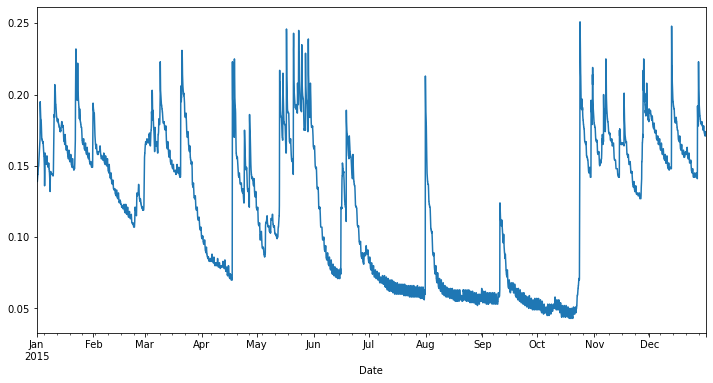

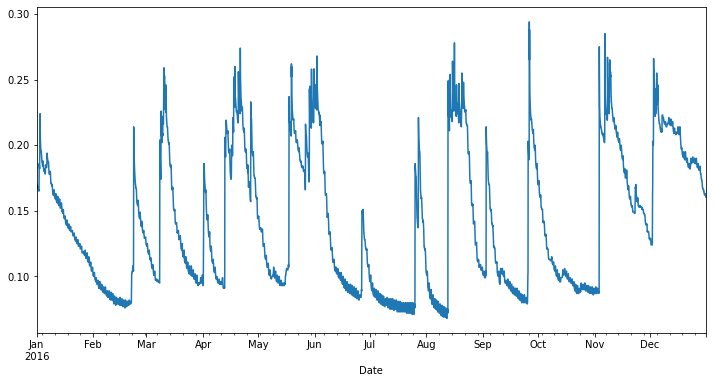

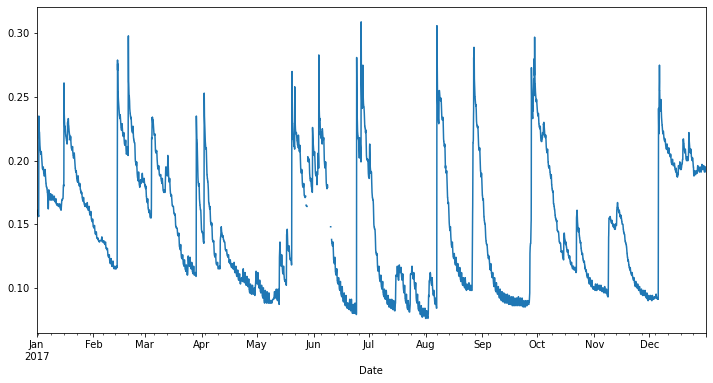

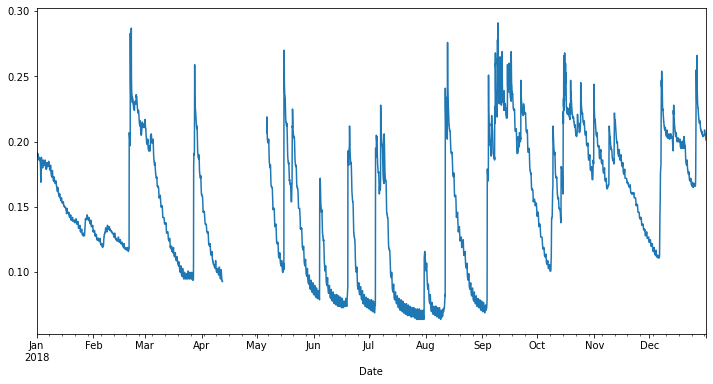

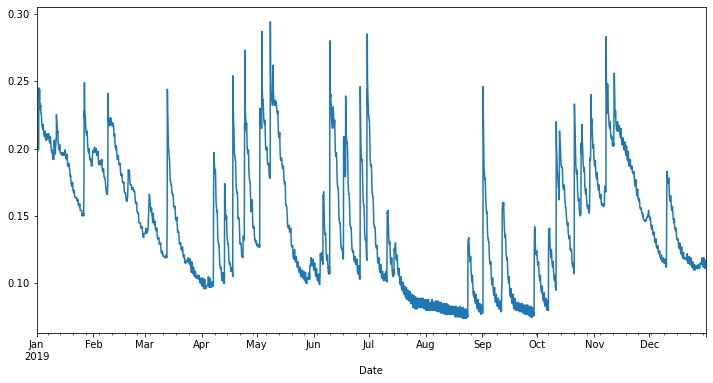

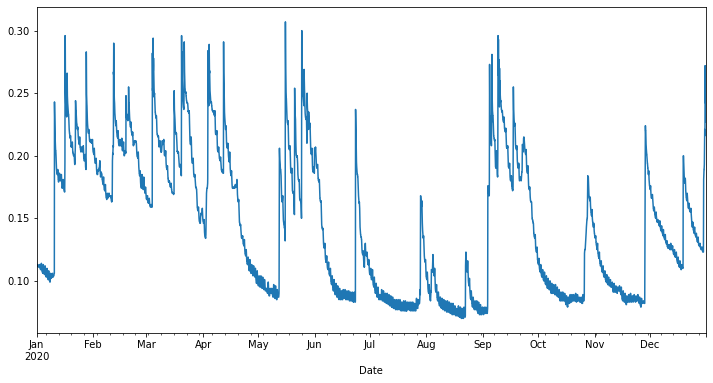

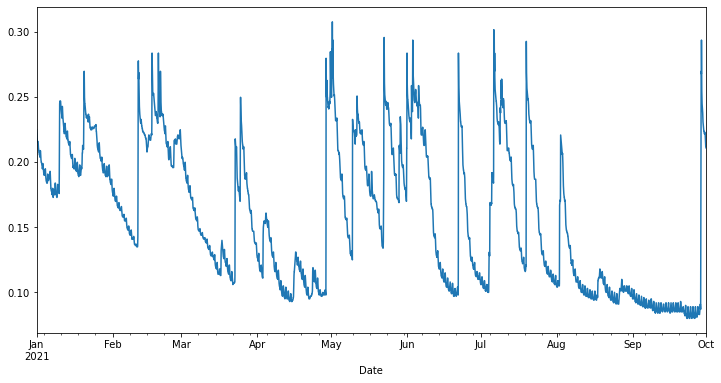

In [10]:
# Docs here https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot
%matplotlib inline
years = [str(item) for item in range(2015, 2022)]

for i in years:
    df_soil[i].SWC_5.plot(figsize=(12,6))
    plt.show()

In [11]:
def findPeaks(SWC5):
    m=False
    peaks=[]
    index=[]
    cooldown=48
    rainpoint=.04
    forward_window=48
    backWindow=-12
    '''
    peaks- values of where we say it rains
    index- index at which it rains
    cooldown- minimum number of points between one rain point and another
    rainPoint- threshold difference to constitue rain
    forwardWindow- how far forward window checks to make sure slope does not continue to increase
    backWindow- how far back it checks the differences in rain values
    '''
    for i in range(24,len(SWC5)-48):
        c=SWC5[i]
        
        
        go=True
        for l in range(1,forward_window):
            if c<SWC5[i+l]:
                go=False
            if go:
                for j in range(backWindow,0):
                    if c-SWC5[i+j]>rainpoint:
                        m=True
                        peaks.append(SWC5[i])
                        index.append(i)
                        break
    for i in range(len(peaks)-1,0,-1):
        if index[i]-index[i-1]<cooldown:
            if peaks[i]>peaks[i-1]:
                peaks.pop(i-1)
                index.pop(i-1)
            else:
                peaks.pop(i)
                index.pop(i)
    return index, peaks
                    

In [ ]:

%matplotlib inline
years = [str(item) for item in range(2015, 2022)]

for i in years:
    q,a=findPeaks(df_soil[i].SWC_5)
    fig=go.Figure()
    fig.add_trace(go.Scatter(x=list(range(1,len(df_soil)+1)),y=df_soil[i].SWC_5, mode='lines', name='raw Data'))
    fig.add_trace(go.Scatter(x=q,y=a, mode='markers', name='rainpoints'))
    fig.show()


As we can see, the algorithim for the most part works- unsure if what is requested is at the excact highpoint (would have been raining for a couple of hours there) or just find when it is leading to a high point- any advice?